In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from models import Route
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END

In [2]:
router_llm = ChatOllama(
    base_url="https://api.ollama.com",
    model="gemma4:31b-cloud",
    temperature=0
)

In [3]:
router = router_llm.with_structured_output(Route)

In [7]:
SUPERVISOR_PROMPT = """
You are the supervisor of a multi-agent personal learning and research assistant.

Your responsibility is to route each user request to exactly one specialized agent.

Available agents:

tutor:
- Explains concepts from the student's course.
- Answers questions using the RAG course knowledge base.
- Handles questions such as "Explain TCP", "What is a semaphore?", or "Explain this course concept."

quiz:
- Generates quizzes based on course content.
- Creates questions and choices from the student's course material.

evaluation:
- Evaluates a student's quiz answers.
- Analyzes quiz performance.
- Identifies mistakes, weak areas, and performance.

planner:
- Creates personalized study plans.
- Uses the student's profile, performance, weak topics, and learning goals.

research:
- Searches the web for scientific information and papers.
- Uses web search and web fetch.
- Handles requests requiring recent or external scientific information.

comparison:
- Compares scientific papers.
- Produces structured comparisons of methodologies, results, strengths, and limitations.

FINISH:
- Use only when the request has already been completed or when no specialized agent is necessary.

Routing rules:

1. Questions about concepts from the student's course should go to tutor.

2. Requests to generate a quiz based on course content should go to quiz.

3. Requests to evaluate quiz answers or analyze quiz performance should go to evaluation.

4. Requests for personalized study plans should go to planner.

5. Requests requiring recent scientific information, web research, or scientific papers should go to research.

6. Requests to compare two or more scientific papers should go to comparison.

7. Choose exactly ONE agent.

8. Do not answer the user's request yourself.

9. The "next" field MUST contain exactly one of:
   - "tutor"
   - "quiz"
   - "evaluation"
   - "planner"
   - "research"
   - "comparison"
   - "FINISH"

10. The "reason" field MUST contain a short explanation of why the selected agent is appropriate.

11. Return ONLY a valid JSON object.

12. Do NOT return Markdown.

13. Do NOT use code fences.

14. Do NOT return text such as:
   "NEXT AGENT: tutor"
   "The next agent is tutor"
   "Agent: tutor"

15. The JSON object MUST have exactly these two fields:
   "next" and "reason".

16. The value of "next" must be one of the allowed agent names listed above.

17. The "reason" should be concise and should explain the routing decision.

Expected output format:

{
    "next": "tutor",
    "reason": "The request asks for an explanation of a course concept."
}
"""

In [8]:
def route_request(user_message: str):

    messages = [
        {
            "role": "system",
            "content": SUPERVISOR_PROMPT
        },
        {
            "role": "user",
            "content": user_message
        }
    ]

    return router.invoke(messages)

In [9]:
decision = route_request(
    "Explain how TCP works."
)

print(decision)

next='tutor' reason="The user is asking for an explanation of a technical concept (TCP), which falls under the tutor agent's responsibility."


In [10]:
decision = route_request(
    "Generate a quiz about TCP."
)

print(decision)

next='quiz' reason='The user is requesting the generation of a quiz based on a specific course topic (TCP).'


In [11]:
decision = route_request(
    "Find recent scientific papers about RAG."
)

print(decision)

next='research' reason='The user is requesting a search for recent scientific papers, which requires web research capabilities.'


In [12]:
from typing import TypedDict

class SupervisorState(TypedDict):
    user_message: str
    next: str
    response: str

In [13]:
def supervisor_node(state: SupervisorState):

    decision = route_request(
        state["user_message"]
    )

    return {
        "next": decision.next
    }

In [14]:
def tutor_node(state: SupervisorState):

    return {
        "response": "Tutor Agent selected."
    }

def quiz_node(state: SupervisorState):

    return {
        "response": "Quiz Agent selected."
    }

def evaluation_node(state: SupervisorState):

    return {
        "response": "Evaluation Agent selected."
    }

def planner_node(state: SupervisorState):

    return {
        "response": "Planner Agent selected."
    }

def research_node(state: SupervisorState):

    return {
        "response": "Research Agent selected."
    }

def comparison_node(state: SupervisorState):

    return {
        "response": "Comparison Agent selected."
    }

In [15]:
graph_builder = StateGraph(SupervisorState)

graph_builder.add_node(
    "supervisor",
    supervisor_node
)
graph_builder.add_node(
    "tutor",
    tutor_node
)

graph_builder.add_node(
    "quiz",
    quiz_node
)

graph_builder.add_node(
    "evaluation",
    evaluation_node
)

graph_builder.add_node(
    "planner",
    planner_node
)

graph_builder.add_node(
    "research",
    research_node
)

graph_builder.add_node(
    "comparison",
    comparison_node
)

In [16]:
graph_builder.add_edge(
    START,
    "supervisor"
)
graph_builder.add_conditional_edges(
    "supervisor",
    lambda state: state["next"],
    {
        "tutor": "tutor",
        "quiz": "quiz",
        "evaluation": "evaluation",
        "planner": "planner",
        "research": "research",
        "comparison": "comparison",
        "FINISH": END,
    }
)
graph_builder.add_edge(
    "tutor",
    END
)

graph_builder.add_edge(
    "quiz",
    END
)

graph_builder.add_edge(
    "evaluation",
    END
)

graph_builder.add_edge(
    "planner",
    END
)

graph_builder.add_edge(
    "research",
    END
)

graph_builder.add_edge(
    "comparison",
    END
)

In [17]:
supervisor_graph = graph_builder.compile()

In [18]:
result = supervisor_graph.invoke(
    {
        "user_message": "Explain how HTTP works.",
        "next": "",
        "response": ""
    }
)
print(result)

{'user_message': 'Explain how HTTP works.', 'next': 'tutor', 'response': 'Tutor Agent selected.'}


In [19]:
result = supervisor_graph.invoke(
    {
        "user_message": "Generate a quiz about HTTP.",
        "next": "",
        "response": ""
    }
)

print(result)

{'user_message': 'Generate a quiz about HTTP.', 'next': 'quiz', 'response': 'Quiz Agent selected.'}


In [20]:
result = supervisor_graph.invoke(
    {
        "user_message": "Create a study plan for my weak topics.",
        "next": "",
        "response": ""
    }
)

print(result)

{'user_message': 'Create a study plan for my weak topics.', 'next': 'planner', 'response': 'Planner Agent selected.'}


In [21]:
result = supervisor_graph.invoke(
    {
        "user_message": "Find recent papers about RAG.",
        "next": "",
        "response": ""
    }
)

print(result)

{'user_message': 'Find recent papers about RAG.', 'next': 'research', 'response': 'Research Agent selected.'}


In [22]:
result = supervisor_graph.invoke(
    {
        "user_message": "Compare these research papers.",
        "next": "",
        "response": ""
    }
)

print(result)

{'user_message': 'Compare these research papers.', 'next': 'comparison', 'response': 'Comparison Agent selected.'}


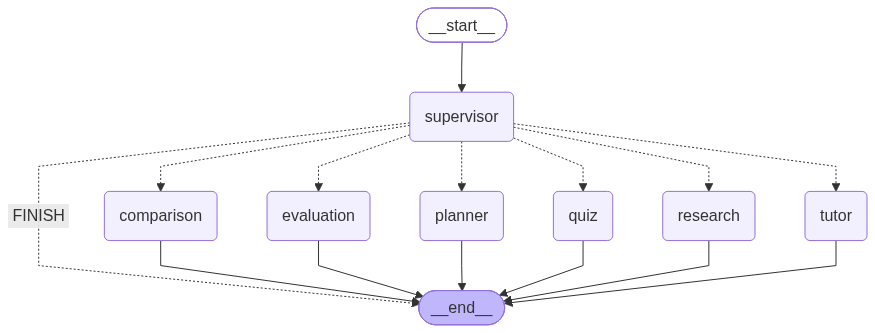

In [23]:
from IPython.display import Image, display

display(
    Image(
        supervisor_graph.get_graph().draw_mermaid_png()
    )
)

In [24]:
result = supervisor_graph.invoke(
    {
        "user_message": "Thank you, that's all.",
        "next": "",
        "response": ""
    }
)

print(result)

{'user_message': "Thank you, that's all.", 'next': 'FINISH', 'response': ''}
